<a href="https://colab.research.google.com/github/Arnav210/CIFAR-10-ML-model/blob/main/Arnav_Mittal_Project_Template_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR 10 Image Classification

![image](https://miro.medium.com/max/1400/1*OSvbuPLy0PSM2nZ62SbtlQ.png)

To build high performance self-driving system, one must first develop a successful machine learning pipeline to recognize objects. In this project, you will be using CIFAR 10 dataset. CIFAR is an acronym that stands for the Canadian Institute For Advanced Research and the CIFAR-10 dataset was developed along with the CIFAR-100 dataset by researchers at the CIFAR institute (this project uses CIFAR-10). The dataset is comprised of 60,000 32×32 pixel color photographs of objects from 10 classes, such as frogs, birds, cats, ships, etc. The class labels and their standard associated integer values are listed below:

Class Index | Class label
--- | ---
`**0**` | **airplane**
`**1**` | **automobile**
`**2**` | **bird**
`**3**` | **cat**
`**4**` | **deer**
`**5**` | **dog**
`**6**` | **frog**
`**7**` | **horse**
`**8**` | **ship**
`**9**` | **truck**



## Load Data

In [ ]:
# Run this code to import libraries
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from keras.datasets import cifar10
import tensorflow as tf

In [ ]:
!wget -qO /root/c.tgz https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz && tar xzf /root/c.tgz -C /root

import pickle, glob

def _b(f):
    d = pickle.load(open(f,'rb'), encoding='bytes')
    return d[b'data'].reshape(-1,3,32,32).transpose(0,2,3,1), np.array(d[b'labels'],'uint8').reshape(-1,1)

def _load():
    X = [_b(f) for f in sorted(glob.glob('/root/cifar-10-batches-py/data_batch_*'))]
    return (np.concatenate([x for x,_ in X]), np.concatenate([y for _,y in X])), _b('/root/cifar-10-batches-py/test_batch')

cifar10.load_data = _load

In [ ]:
# Run this code to load the dataset
# cifar10 = tf.keras.datasets.cifar10
(training_images, training_labels), (testing_images, testing_labels) = cifar10.load_data()

In [ ]:
# Run this code to see the sizes / shapes of our data
print("Training images size: ", training_images.shape)
print("Training labels size: ", training_labels.shape)
print("Testing images size: ", testing_images.shape)
print("Testing labels size: ", testing_labels.shape)

Training images size:  (50000, 32, 32, 3)
Training labels size:  (50000, 1)
Testing images size:  (10000, 32, 32, 3)
Testing labels size:  (10000, 1)


In [ ]:
# Run this code to see the labels for the images
training_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
# Run this code to create a dictionary that translates the labels to meaningful strings
class_labels = {
    0 : "airplane",
    1 : "automobile",
    2 : "bird",
    3 : "cat",
    4 : "deer",
    5 : "dog",
    6 : "frog",
    7 : "horse",
    8 : "ship",
    9 : "truck"
}

Image label=6, class frog


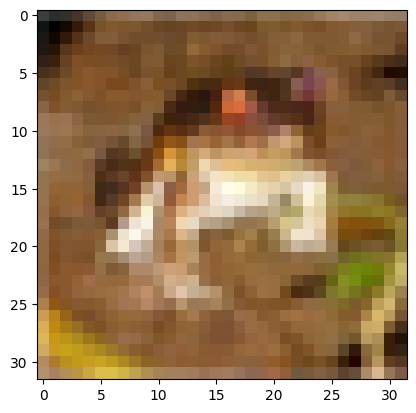

In [ ]:
# Run this code to show the first training image
plt.imshow(training_images[0])
print("Image label=" + str(training_labels[0][0]) + ", class " + class_labels[training_labels[0][0]])

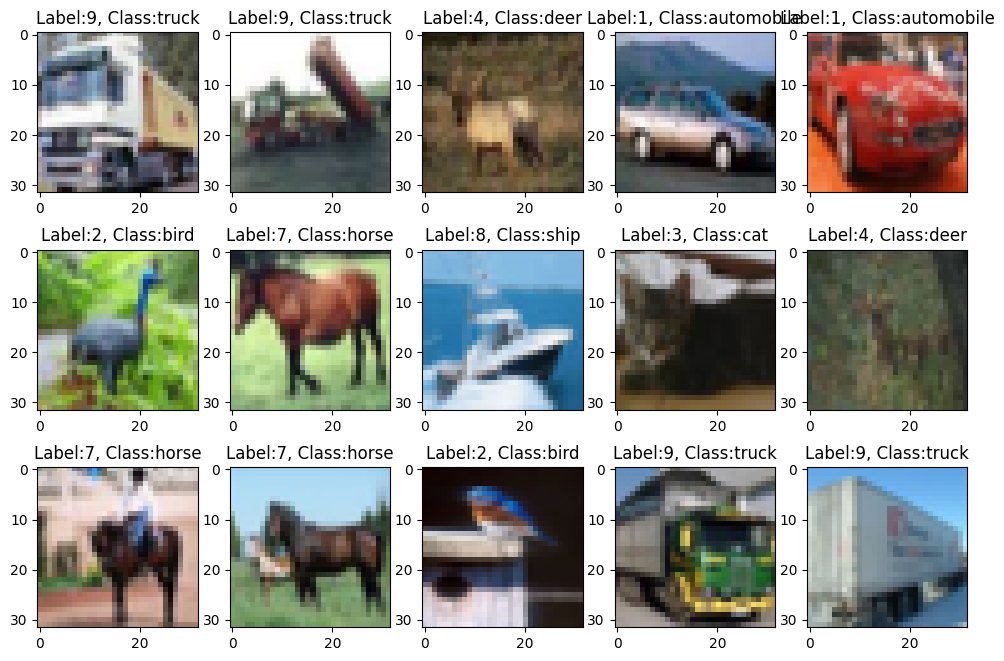

In [ ]:
# Run this code to show 15 images
fig = plt.figure(figsize=(12, 8))
columns = 5
rows = 3
for i in range(1, columns*rows +1):
    img = training_images[i] # get an image, defined as "img"
    fig.add_subplot(rows, columns, i) # create subplot (row index, col index, which number of plot)
    plt.title("Label:" + str(training_labels[i][0]) + ", Class:" + class_labels[training_labels[i][0]]) # plot the image, along with its label
    plt.imshow(img)
plt.show()

## Exploratory Data Analysis

Ideas for this section:
- Figure out how many images are from each class
- Compare images within a single class (e.g. all the frogs). What are some of the features that are similar between them. What are some of the differences?
- Print one image from every class. What are some of the features that are similar between classes. What are some of the differences? Which classes might get easily confused.

/tmp/ipykernel_16176/885332883.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_counts[class_labels[int(label)]] += 1
/tmp/ipykernel_16176/885332883.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == i:


Total counts: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


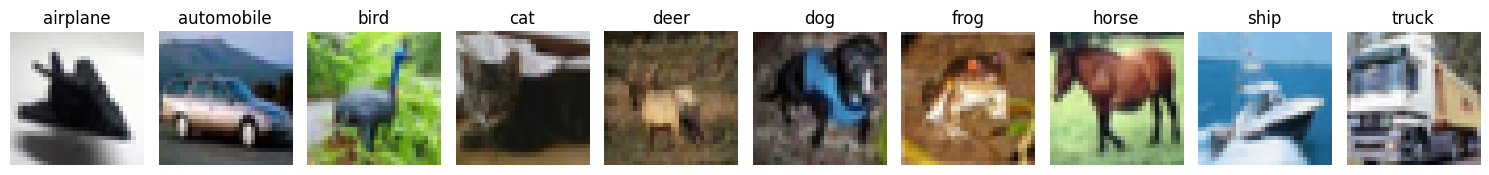

/tmp/ipykernel_16176/885332883.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == 6:


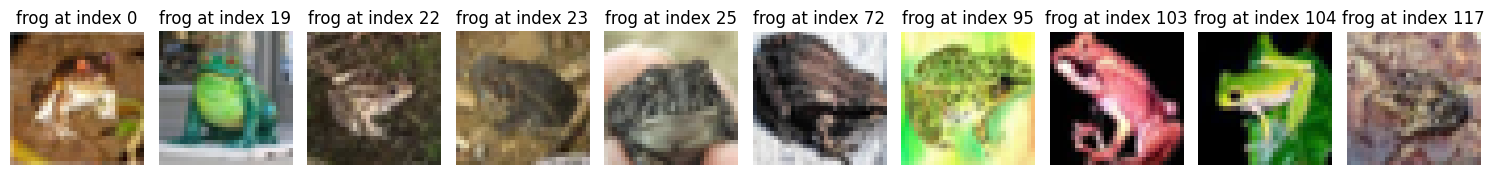

In [ ]:
# Your code here

label_counts = {
    "airplane": 0,
    "automobile": 0,
    "bird": 0,
    "cat": 0,
    "deer": 0,
    "dog": 0,
    "frog": 0,
    "horse": 0,
    "ship": 0,
    "truck": 0
}

for label in training_labels:
    label_counts[class_labels[int(label)]] += 1

print(f"Total counts: {label_counts}")

plt.figure(figsize=(15, 3))

for i in range(10):
  for index, label in enumerate(training_labels):
    if int(label) == i:
      plt.subplot(1, 10, i + 1)
      plt.imshow(training_images[index])
      plt.title(f"{class_labels[i]}")
      plt.axis("off")
      break

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 3))

count = 0

for index, label in enumerate(training_labels):
  if int(label) == 6:
    plt.subplot(1, 10, count + 1)
    plt.imshow(training_images[index])
    plt.title(f"frog at index {index}")
    plt.axis("off")
    count += 1
  if count == 10:
    break

plt.tight_layout()
plt.show()

## Baseline Model

1) Create a traditional neural network model for classification

2) Print your final train and test accuracies

3) Print images that your model misclassified. Analyze: Why do you think it misclassified those images?

In [ ]:
# Your code here

# rescale images
training_images = training_images / 255.0
testing_images = testing_images / 255.0

# build model
from tensorflow.keras.layers import Dense

base_model = tf.keras.models.Sequential ([
    tf.keras.layers.Flatten(),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

base_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# train model with training data and a validation split
base_model.fit(training_images, training_labels, epochs = 10, validation_split = 0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3105 - loss: 1.8927 - val_accuracy: 0.3564 - val_loss: 1.7828
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3866 - loss: 1.7048 - val_accuracy: 0.3932 - val_loss: 1.6846
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4178 - loss: 1.6226 - val_accuracy: 0.4293 - val_loss: 1.6106
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4410 - loss: 1.5621 - val_accuracy: 0.4318 - val_loss: 1.5961
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4540 - loss: 1.5244 - val_accuracy: 0.4460 - val_loss: 1.5714
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4691 - loss: 1.4884 - val_accuracy: 0.4409 - val_loss: 1.5701
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4748 - loss: 1.4621 - val_accuracy: 0.4547 - val_loss: 1.5224
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4830 - loss: 1.4367 - 

In [ ]:
# get predictions from testing data
predictions = base_model.predict(testing_images)
predictions = np.argmax(predictions, axis = 1)

test_loss, test_accuracy = base_model.evaluate(testing_images, testing_labels)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4736 - loss: 1.4707
Test Loss:     1.4707
Test Accuracy: 47.36%


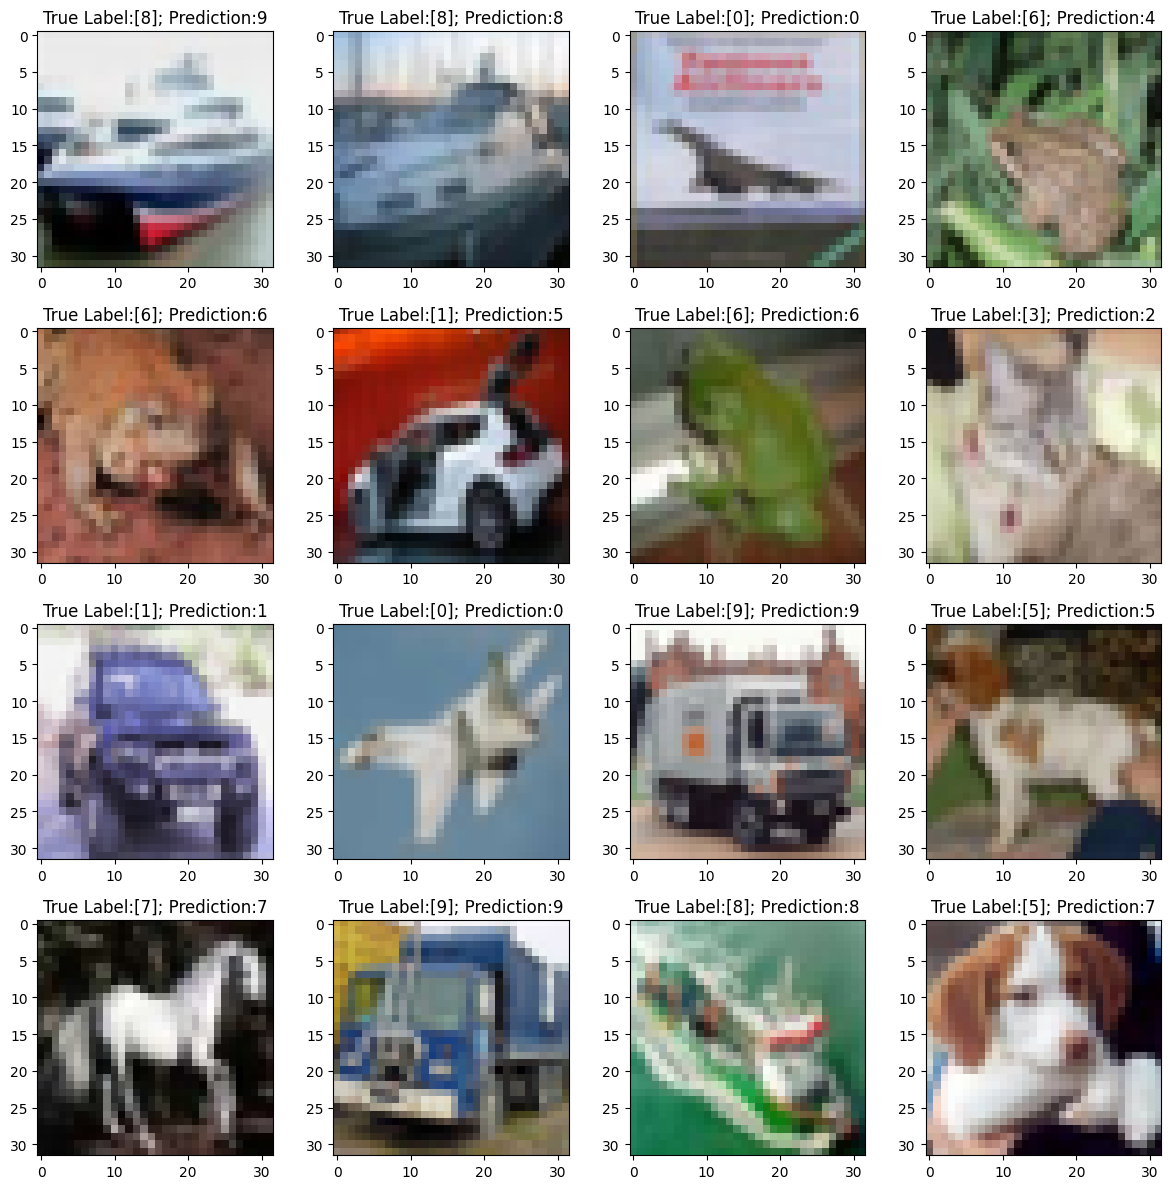

In [ ]:
# plot first few predictions
fig = plt.figure(figsize=(12, 12))
columns = 4
rows = 4

for i in range(1, columns*rows +1):
    img = testing_images[i] # get a test image
    fig.add_subplot(rows, columns, i) # place it in our grid
    plt.title("True Label:" + str(testing_labels[i]) + "; Prediction:" + str(predictions[i])) # title with actal digit and predicted digit
    plt.imshow(img, cmap=plt.cm.binary)

plt.tight_layout()
plt.show()

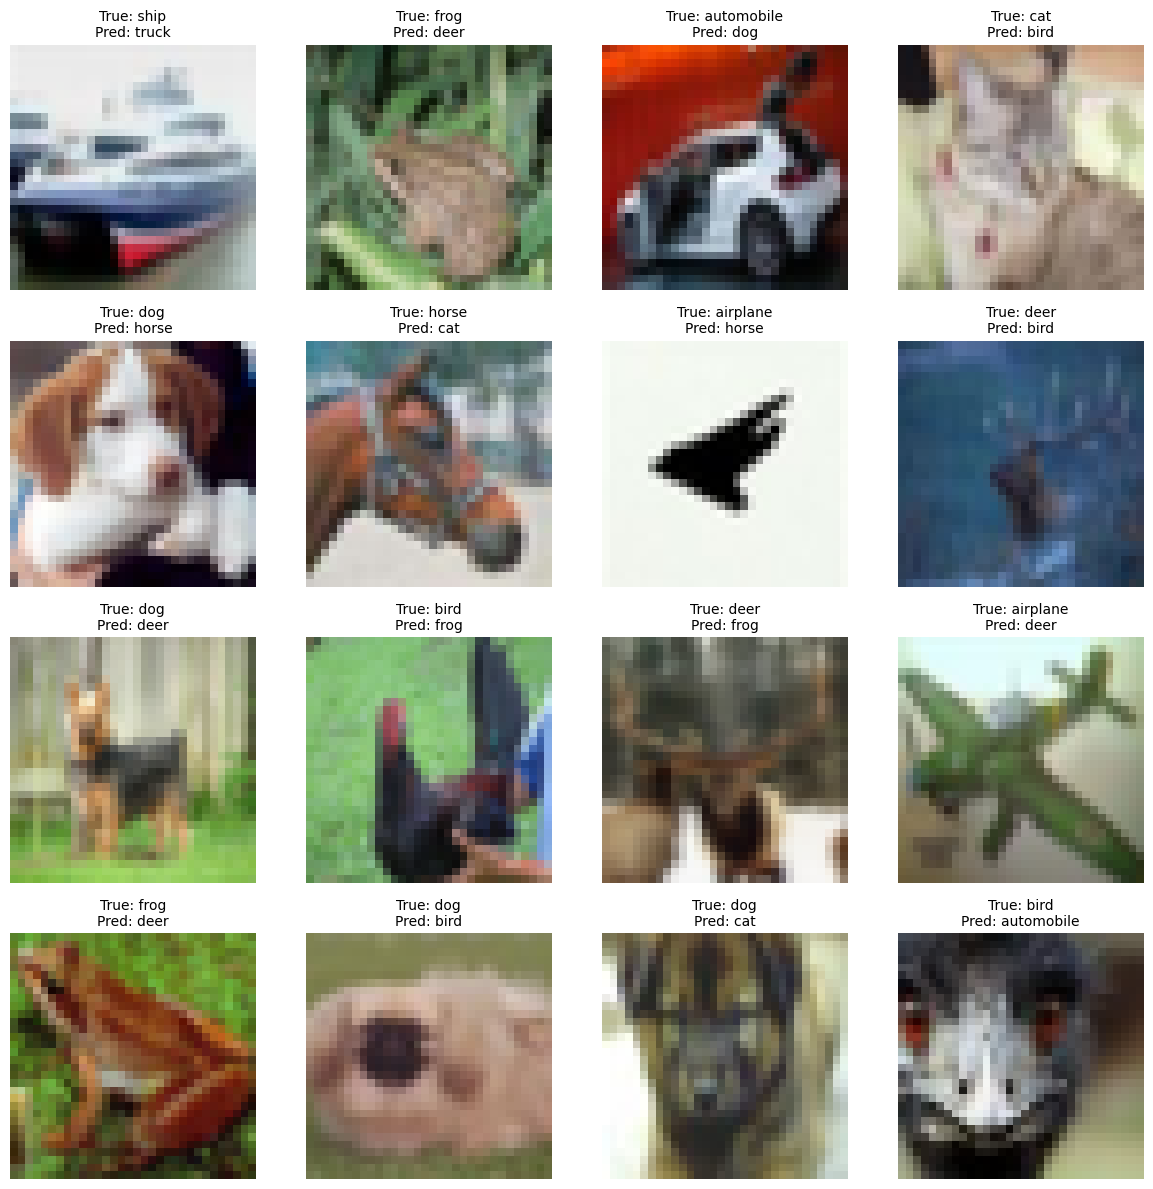

In [ ]:
# plot first few incorrect predictions
flat_labels = testing_labels.squeeze()

wrong_idxs = np.where(flat_labels != predictions)[0]

fig = plt.figure(figsize=(12, 12))
columns = 4
rows = 4

for i in range(columns * rows):
    idx = wrong_idxs[i]
    img = testing_images[idx]
    fig.add_subplot(rows, columns, i + 1)
    true_name = class_labels[int(flat_labels[idx])]
    pred_name = class_labels[int(predictions[idx])]

    plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=10)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Advanced Model & Model Tuning

1) Create a traditional convolutional neural network (CNN) model for classification

2) Plot your training and testing accuracies; then, plot images that your model misclassified.

3) Iterate on steps 1 & 2, adjusting your CNN model architecture to try and adchieve higher testing accuracies.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, RandomFlip
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Build Model Architecture
model = tf.keras.models.Sequential([
    Input(shape=(32, 32, 3)),

    # Safe Augmentation: Only horizontal flips (no blur or pixel distortion)
    RandomFlip("horizontal"),

    # --- Block 1 ---
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Block 2 ---
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Block 3 ---
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- Classifier ---
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

# 2. Compile Model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           51

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
# 3. Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # Cuts learning rate in half when val_loss plateaus
    patience=3,         # Triggers after 3 stagnant epochs
    min_lr=1e-6
)

# 4. Train Model
history = model.fit(
    training_images, training_labels,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler]
)

313/313 - 2s - 6ms/step - accuracy: 0.8794 - loss: 0.4183


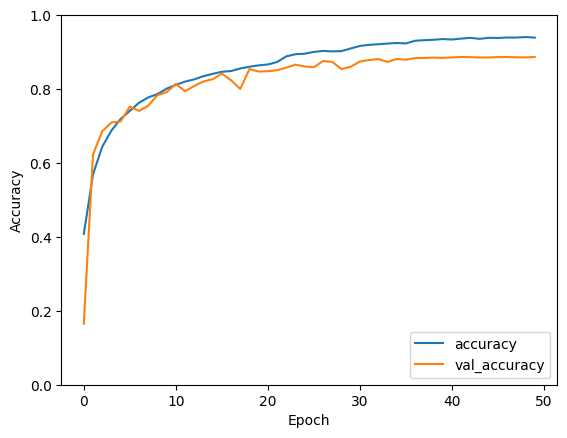

In [ ]:
# get testing accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1]) # recall accuracy is between 0 to 1
plt.legend(loc='lower right') # specify location of the legend

test_loss, test_acc = model.evaluate(testing_images, testing_labels, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


/tmp/ipykernel_648/3820130854.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel("Actual: {}".format(class_labels[int(testing_labels[idx])]))


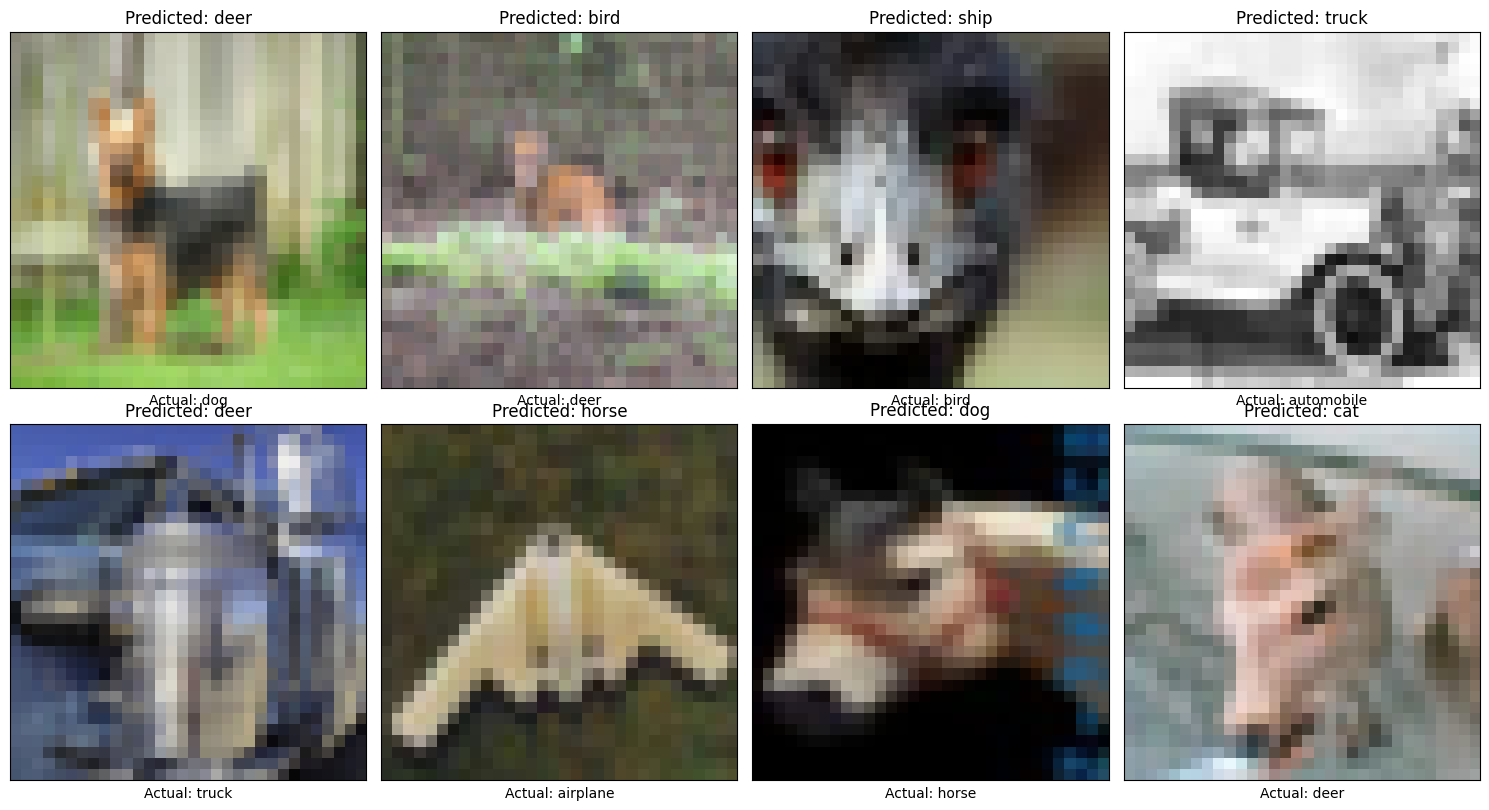

In [ ]:
# get incorrect predictions
predicted_classes = model.predict(testing_images)
predicted_classes = np.argmax(predicted_classes, axis=1)

incorrect = np.nonzero(predicted_classes != testing_labels.squeeze())[0]

plt.figure(figsize=(15, 8))

for j, idx in enumerate(incorrect[0:8]):
    plt.subplot(2, 4, j+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(testing_images[idx].squeeze())
    plt.title("Predicted: {}".format(class_labels[int(predicted_classes[idx])]))
    plt.xlabel("Actual: {}".format(class_labels[int(testing_labels[idx])]))

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
K = tf.keras

# 1. Load VGG16 base model
base_model = K.applications.vgg16.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3)
)

# CRITICAL: Freeze base model so pre-trained weights aren't destroyed
base_model.trainable = False

# 2. Build Sequential Model
model = K.Sequential([
    base_model,
    K.layers.Flatten(),
    K.layers.Dense(256, activation='relu'),
    K.layers.BatchNormalization(),
    K.layers.Dropout(0.5),
    K.layers.Dense(10, activation='softmax')
])

# 3. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,898,186 (60.65 MB)

 Trainable params: 1,182,986 (4.51 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
# 4. Callbacks
early_stopping = K.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_scheduler = K.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# 5. Fit
history = model.fit(
    x=training_images,
    y=training_labels,
    batch_size=128,
    validation_split=0.2,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.3478 - loss: 1.8334 - val_accuracy: 0.1034 - val_loss: 28.1348 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.4007 - loss: 1.6912 - val_accuracy: 0.0994 - val_loss: 16.8982 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.4107 - loss: 1.6645 - val_accuracy: 0.0980 - val_loss: 24.3818 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.4163 - loss: 1.6541 - val_accuracy: 0.0992 - val_loss: 18.1046 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.4180 - loss: 1.6473 - val_accuracy: 0.0998 - val_loss: 9.1305 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.4219 - loss: 1.6427 - val_accuracy: 0.1033 - val_loss: 19.7341 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy

KeyboardInterrupt: 

313/313 - 4s - 14ms/step - accuracy: 0.6146 - loss: 1.1057


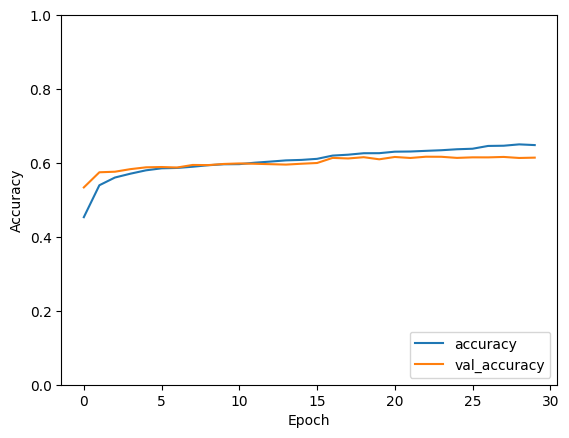

In [ ]:
# get testing accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1]) # recall accuracy is between 0 to 1
plt.legend(loc='lower right') # specify location of the legend

test_loss, test_acc = model.evaluate(testing_images, testing_labels, verbose=2)

## Interpretation and Future Work

Present and also interpret your experimental performance. Comment on potential future work or research questions that your project leads to.

**Type your response here (double-click):**